In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets

In [2]:
def central_equation_entry(g_vectors,potential,k_vec,i,j,):
    """ returns the (i,j)th entry of the central matrix """
    gi = g_vectors[i]
    gj = g_vectors[j]

    if i==j:
        val = np.dot(k_vec-gi,k_vec-gi)
    else:
        val = potential[i,j]
    return val

def central_equation(
    g_vectors,
    potential,
    k_vec
):
    """ loops over potential indices to make central matrix """
    array = np.zeros_like(potential)
    n,m = array.shape
    for i in range(n):
        for j in range(m):
            array[i,j] = central_equation_entry(g_vectors,potential,k_vec,i,j)
    return array

def central_equation_eigenvalues(
    g_vectors,
    potential,
    k_vec
):
    """ diagonalizes central matrix """
    array = central_equation(g_vectors,potential,k_vec)
    return np.sort(np.linalg.eigvalsh(array).real)[:3]

In [3]:
potential_1d = np.zeros((5,5))
g_vectors_1d = np.arange(-2,3)[:,None]
k_vecs_1d = np.linspace(-0.5,0.5,48+1) # first BZ

bandstructure_1d = np.array([
    central_equation_eigenvalues(
        g_vectors_1d,
        potential_1d,
        k
    )
    for k in k_vecs_1d
])

bandstructure_1d -= bandstructure_1d[24,0]

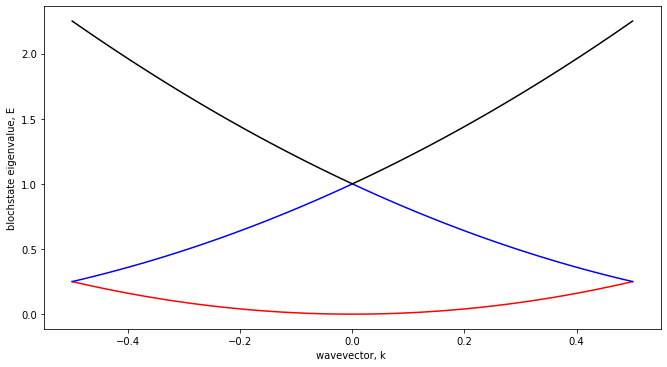

In [4]:
dpi = 72
with plt.ioff():
    fig, ax = plt.subplots(figsize=(675/dpi,375/dpi),dpi=dpi)
ax.set_prop_cycle(color=['red', 'blue','black'])
lines = ax.plot(k_vecs_1d,bandstructure_1d)
ax.set(
    xlabel=r"wavevector, k ",
    ylabel="blochstate eigenvalue, E"
)
fig.canvas.resizable = False
fig.canvas.header_visible = False
fig.canvas.footer_visible = False
fig.canvas.toolbar_visible = True

fig.canvas.toolbar_position = 'bottom'
fig.tight_layout()
None

In [5]:
layout = ipywidgets.Layout(width='330px',height='30px')
style = {
    'description_width': 'initial',
}

def update_blochstates(change):
    """ """
    V0 = change["new"]
    vec = np.full(4,V0)
    potential_1d = np.diag(vec,1) + np.diag(vec,-1)
    
    bandstructure_1d = np.array([
        central_equation_eigenvalues(
            g_vectors_1d,
            potential_1d,
            k
        )
        for k in k_vecs_1d
    ])
    bandstructure_1d -= bandstructure_1d[24,0]

    lines[0].set_ydata(bandstructure_1d[:,0])
    lines[1].set_ydata(bandstructure_1d[:,1])
    lines[2].set_ydata(bandstructure_1d[:,2])
    fig.canvas.draw_idle()
    return None

V0_slider = ipywidgets.FloatSlider(
    min=0,
    max=0.5,
    step=0.025,
    layout=layout,
    style=style,
    description=r"potential strength, V$_0$"
)

V0_slider.observe(update_blochstates,"value")

In [6]:
import abtem
import abtem.bloch
import ase

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

abtem.config.set({"dask.lazy":False});

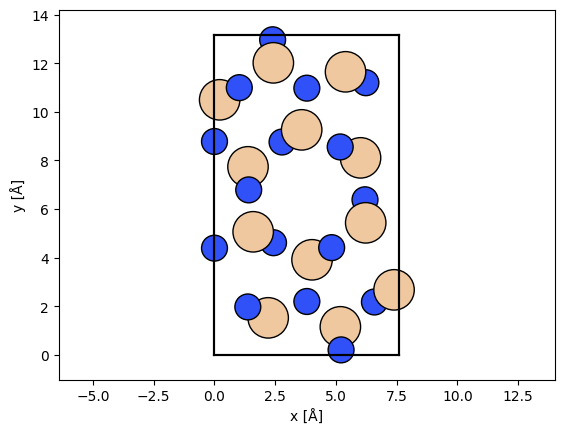

In [7]:
Si3N4_crystal = ase.Atoms(
    "Si6N8",
    scaled_positions=[
        (0.82495, 0.59387, 0.75),
        (0.23108, 0.82495, 0.25),
        (0.59387, 0.76892, 0.25),
        (0.40614, 0.23108, 0.75),
        (0.76892, 0.17505, 0.75),
        (0.17505, 0.40613, 0.25),
        
        (0.66667, 0.33334, 0.75),
        (0.33334, 0.66667, 0.25),
        (0.66986, 0.70066, 0.75),
        (0.96920, 0.66986, 0.25),
        (0.70066, 0.03081, 0.25),
        (0.29934, 0.96919, 0.75),
        (0.33015, 0.29934, 0.25),
        (0.03081, 0.33014, 0.75),
    ],
    cell=[7.6045, 7.6045, 2.9052, 90, 90, 120],
    pbc=True
)
Si3N4_orthorhombic = abtem.orthogonalize_cell(Si3N4_crystal)
abtem.show_atoms(Si3N4_orthorhombic)
plt.show()

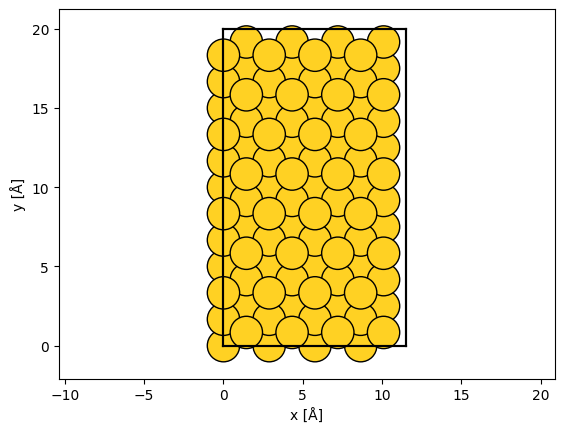

In [8]:
from ase.build import fcc111
lc=4.08
unit_cell = fcc111('Au', size=(2, 2, 12), a=lc, vacuum=lc, orthogonal=False)
nanoparticle = abtem.orthogonalize_cell(unit_cell) * (2,2,1)
# nanoparticle.center(vacuum=10, axis=0)
# nanoparticle.center(vacuum=10, axis=1)
abtem.show_atoms(nanoparticle)
plt.show()
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    nanoparticle,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.5,
    scale=1,
)
abtem.show_atoms(
    nanoparticle,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
abtem.show_atoms(
    nanoparticle,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
fig.tight_layout();

In [9]:
g_max = 0.9
sg_max = 0.1
thermal_sigma = 0.1
energy = 300e3

structure_factor = abtem.bloch.StructureFactor(
    nanoparticle,
    g_max=g_max,
    thermal_sigma=thermal_sigma,
    parametrization="lobato"
)
print(len(structure_factor.g_vec))
bloch_waves = abtem.bloch.BlochWaves(
    structure_factor=structure_factor,
    energy=energy,
    sg_max=sg_max,
)

kinematical_diffraction_pattern = bloch_waves.get_kinematical_diffraction_pattern()

/home/wdekleijne/git-repos/willem-playground/.venv/lib/python3.12/site-packages/abtem/bloch/utils.py:552: UserWarning: Something went wrong with the centering detection using primitive. Set manually to mute warning.
  warnings.warn(


24003


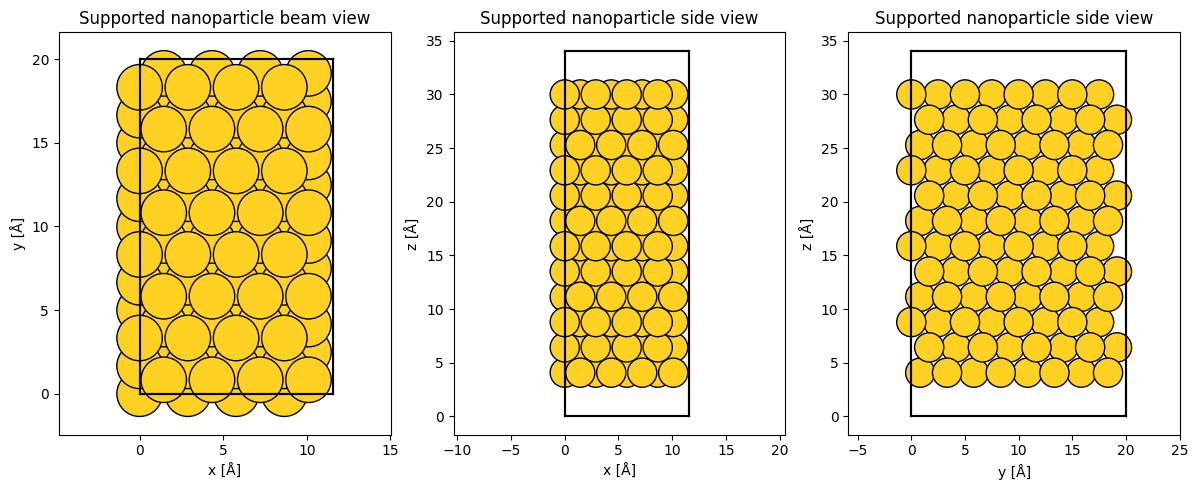

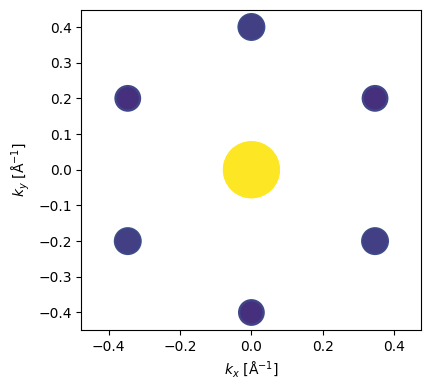

In [10]:
#| label: app:blochwave_kinematical
kinematical_diffraction_pattern.block_direct(
).show(
    scale=0.08,
    power=0.5,
    annotations=False,
    figsize=(4,4)
);
plt.show()

In [11]:
cell_thickness = Si3N4_orthorhombic.cell[2,2]
cell_thicknesses = np.arange(cell_thickness*50,cell_thickness*400,cell_thickness*100)

In [12]:
cell_thickness = nanoparticle.cell[2,2]
cell_thicknesses = np.arange(cell_thickness*1,cell_thickness*20,cell_thickness*4)
cell_thicknesses

array([ 34.07148008, 170.35740041, 306.64332073, 442.92924106,
       579.21516138])

In [13]:

bloch_waves.calculate_diffraction_patterns(
    cell_thicknesses,
    lazy=False,
).block_direct(
).show(
    scale=0.08,
    power=0.5,
    explode=True,
    annotations=False,
    common_color_scale=True,
    figsize=(12,4),
    cbar=True
);

In [14]:
x_angles = np.linspace(0,120e-3,4)
y_angles = np.linspace(120e-3,0,4)
xy_angles = np.dstack(np.meshgrid(x_angles,y_angles,indexing='ij')).reshape((-1,2))

orientation_matrices = Rotation.from_euler('xy',xy_angles).as_matrix()

bloch_matrices = [
    abtem.bloch.BlochWaves(
        structure_factor=structure_factor,
        energy=energy,
        sg_max=sg_max,
        orientation_matrix=orientation,
    ) for orientation in orientation_matrices
]

dps = [
    bloch.calculate_diffraction_patterns(
        thicknesses=np.array([cell_thicknesses[0]]),
        lazy=False,
    ).block_direct(
    ) for bloch in bloch_matrices
]

In [15]:
#| label: app:blochwave_tilted

fig = plt.figure(figsize=(12,12))
axes = abtem.visualize.axes_grid.AxesGrid(
    fig=fig,
    ncols=4,
    nrows=4,
)._axes

y_indices = np.tile(np.arange(4),4)
x_indices = np.repeat(np.arange(4),4)

for ax, dp, x_ind, y_ind in zip(axes.ravel(),dps,x_indices, y_indices):
    dp.show(
        scale=0.08,
        power=0.5,
        annotations=False,
        ax=ax
    )
    if x_ind == 0:
        label = ax.get_ylabel()
        ax.set_ylabel(f"x-tilt: {x_angles[3-y_ind]*1e3:.0f} mrad\n"+label)
    if y_ind == 3:
        ax.set_title(f"y-tilt: {y_angles[3-x_ind]*1e3:.0f} mrad",fontsize=10)

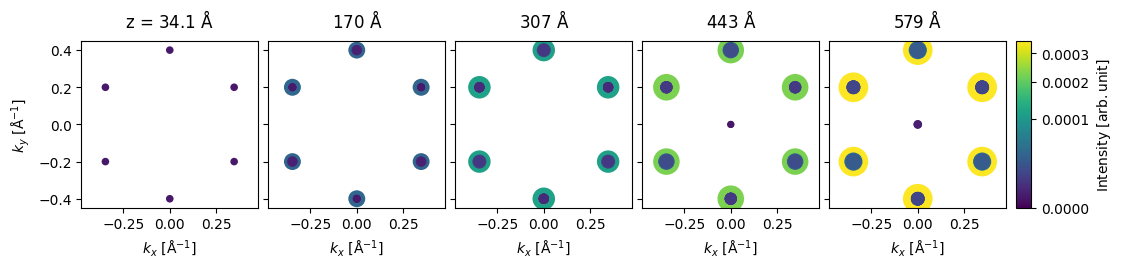

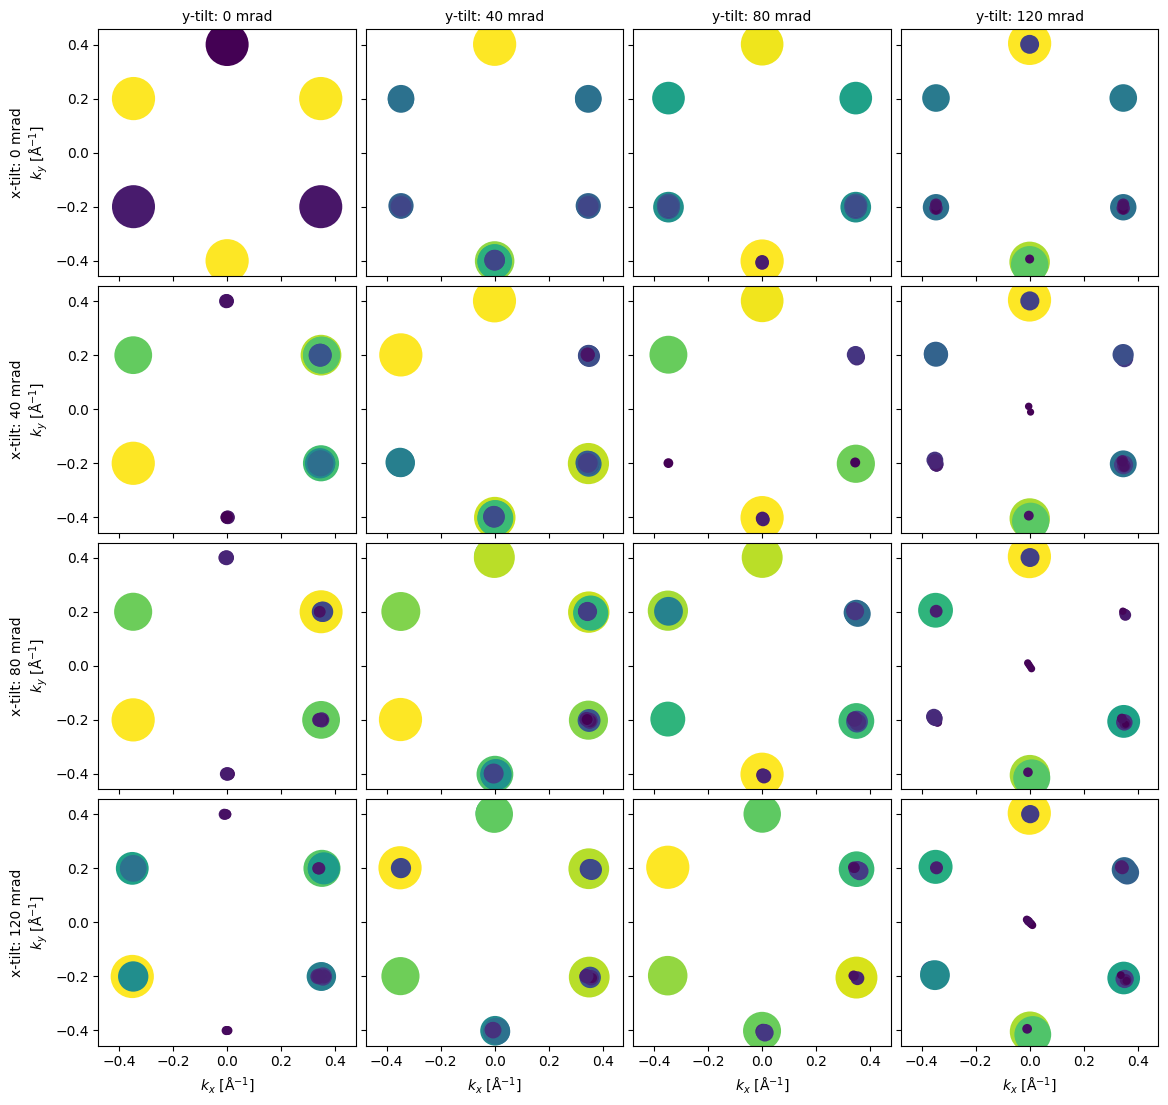

In [16]:
plt.show()